### Plain SinBERT-large Fine-Tuning Model
This notebook fine-tunes the plain SinBERT-large (RoBERTa-based) model for Sinhala emotion classification **without** any CNN layers, using `RobertaForSequenceClassification`. Results can be directly compared with the SinBERT+CNN model.


### Imports


In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, RobertaForSequenceClassification
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


### Load Dataset


In [2]:
df = pd.read_csv('./processed/processed_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

num_labels = len(df['label'].unique())
label_names = sorted(df['label'].unique())
label2idx = {label: idx for idx, label in enumerate(label_names)}
idx2label = {idx: label for label, idx in label2idx.items()}
print(f"\nNumber of labels: {num_labels}")
print(f"Label mapping: {label2idx}")


Dataset shape: (3800, 2)
Label distribution:
label
joy         1050
disgust      720
sadness      679
anger        597
surprise     576
fear         178
Name: count, dtype: int64

Number of labels: 6
Label mapping: {'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}


|### Tokenizer


In [3]:
tokenizer = AutoTokenizer.from_pretrained("NLPC-UOM/SinBERT-large")


### Dataset Class


In [4]:
class SinhalaEmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.label2idx = {label: idx for idx, label in enumerate(sorted(set(labels)))}
        self.labels = [self.label2idx[label] for label in labels]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

### Plain SinBERT Model Definition
This uses `RobertaForSequenceClassification` directly — a linear classification head on top of the pooled SinBERT output. No CNN layers are added. AdamW is used as the optimizer with weight decay for proper regularization.


In [5]:
class PlainSinBERT(nn.Module):
    """
    Plain SinBERT model for sequence classification.
    Uses RobertaForSequenceClassification with a linear head on top of the [CLS] token.
    No CNN layers — serves as a baseline for comparison.
    """
    def __init__(self, num_labels, dropout_rate=0.1, pretrained_model_name="NLPC-UOM/SinBERT-large"):
        super(PlainSinBERT, self).__init__()
        self.bert = RobertaForSequenceClassification.from_pretrained(
            pretrained_model_name,
            num_labels=num_labels,
            hidden_dropout_prob=dropout_rate,
            attention_probs_dropout_prob=dropout_rate,
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits


### Training Function with Early Stopping


In [6]:
def train_model_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, device, epochs=10, patience=2):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).float().sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * input_ids.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).float().sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break

    return train_losses, train_accuracies, val_losses, val_accuracies


### Evaluation Function


In [7]:
def evaluate_metrics(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    return acc, precision, recall, f1


### Data Preparation


In [8]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

BATCH_SIZE = 16

train_dataset = SinhalaEmotionDataset(
    texts=df_train['text'].tolist(),
    labels=df_train['label'].tolist(),
    tokenizer=tokenizer
)

test_dataset = SinhalaEmotionDataset(
    texts=df_test['text'].tolist(),
    labels=df_test['label'].tolist(),
    tokenizer=tokenizer
)

train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Data loaders ready.")


Data loaders ready.


### Class Weights & Loss Function


In [9]:
labels_array = df_train['label'].values
class_sample_count = np.array([np.sum(labels_array == t) for t in sorted(np.unique(labels_array))])
weight = 1. / class_sample_count
class_weights = torch.tensor(weight, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"Class weights (from training set only): {class_weights}")


Class weights (from training set only): tensor([0.0021, 0.0017, 0.0070, 0.0012, 0.0018, 0.0022], device='cuda:0')


### Hyperparameter Tuning (Grid Search)
The hyperparameters tuned for the plain model are:
- **learning_rate**: Controls the step size of AdamW optimizer updates
- **dropout_rate**: Controls regularization in the transformer layers
- **weight_decay**: The decoupled weight decay in AdamW for better generalization


In [10]:
NUM_FROZEN_LAYERS = 12

def freeze_bottom_layers(model, num_frozen_layers=NUM_FROZEN_LAYERS):
    for param in model.bert.roberta.embeddings.parameters():
        param.requires_grad = False
    for i in range(num_frozen_layers):
        for param in model.bert.roberta.encoder.layer[i].parameters():
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Frozen: embeddings + bottom {num_frozen_layers} encoder layers | Trainable: {trainable:,}/{total:,} ({100*trainable/total:.1f}%)")


In [11]:
param_grid = {
    'learning_rate': [2e-5, 3e-5],
    'dropout_rate': [0.1, 0.2],
    'weight_decay': [0.01, 0.1],
}

all_combinations = list(itertools.product(
    param_grid['learning_rate'],
    param_grid['dropout_rate'],
    param_grid['weight_decay'],
))

results = []

for lr, drop, wd in tqdm(all_combinations, desc='Hyperparameter Tuning'):
    model = PlainSinBERT(
        num_labels=num_labels,
        dropout_rate=drop,
    ).to(device)
    freeze_bottom_layers(model)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=wd)

    train_model_with_early_stopping(
        model=model,
        train_loader=train_data_loader,
        val_loader=test_data_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=10,
        patience=2
    )

    acc, precision, recall, f1 = evaluate_metrics(model, test_data_loader, device)
    results.append({
        'params': f"lr={lr}, drop={drop}, wd={wd}",
        'learning_rate': lr,
        'dropout_rate': drop,
        'weight_decay': wd,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    print(f"  lr={lr}, drop={drop}, wd={wd} → Acc={acc:.4f}, F1={f1:.4f}")


Hyperparameter Tuning:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 595,206/125,982,726 (0.5%)
Epoch 1/10 - Train Loss: 1.6703, Train Acc: 0.3645, Val Loss: 1.5077, Val Acc: 0.4934
Epoch 2/10 - Train Loss: 1.4836, Train Acc: 0.4836, Val Loss: 1.3901, Val Acc: 0.5224
Epoch 3/10 - Train Loss: 1.3920, Train Acc: 0.5079, Val Loss: 1.3210, Val Acc: 0.5355
Epoch 4/10 - Train Loss: 1.3456, Train Acc: 0.5247, Val Loss: 1.2653, Val Acc: 0.5303
Epoch 5/10 - Train Loss: 1.2991, Train Acc: 0.5372, Val Loss: 1.2356, Val Acc: 0.5447
Epoch 6/10 - Train Loss: 1.2803, Train Acc: 0.5289, Val Loss: 1.2089, Val Acc: 0.5382
Epoch 7/10 - Train Loss: 1.2473, Train Acc: 0.5526, Val Loss: 1.1902, Val Acc: 0.5500
Epoch 8/10 - Train Loss: 1.2275, Train Acc: 0.5526, Val Loss: 1.1727, Val Acc: 0.5632
Epoch 9/10 - Train Loss: 1.2168, Train Acc: 0.5576, Val Loss: 1.1637, Val Acc: 0.5763
Epoch 10/10 - Train Loss: 1.2032, Train Acc: 0.5592, Val Loss: 1.1508, Val Acc: 0.5737
  lr=2e-05, drop=0.1, wd=0.01 → Acc=0.5737, F1=0.5471

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 595,206/125,982,726 (0.5%)
Epoch 1/10 - Train Loss: 1.6831, Train Acc: 0.3401, Val Loss: 1.4959, Val Acc: 0.4789
Epoch 2/10 - Train Loss: 1.5125, Train Acc: 0.4470, Val Loss: 1.3811, Val Acc: 0.5105
Epoch 3/10 - Train Loss: 1.4320, Train Acc: 0.4845, Val Loss: 1.3222, Val Acc: 0.5329
Epoch 4/10 - Train Loss: 1.3914, Train Acc: 0.4974, Val Loss: 1.2676, Val Acc: 0.5395
Epoch 5/10 - Train Loss: 1.3546, Train Acc: 0.4967, Val Loss: 1.2473, Val Acc: 0.5368
Epoch 6/10 - Train Loss: 1.3446, Train Acc: 0.4934, Val Loss: 1.2417, Val Acc: 0.5368
Epoch 7/10 - Train Loss: 1.3159, Train Acc: 0.5016, Val Loss: 1.2153, Val Acc: 0.5553
Epoch 8/10 - Train Loss: 1.3115, Train Acc: 0.5145, Val Loss: 1.1974, Val Acc: 0.5434
Epoch 9/10 - Train Loss: 1.2943, Train Acc: 0.5316, Val Loss: 1.1946, Val Acc: 0.5711
Epoch 10/10 - Train Loss: 1.2817, Train Acc: 0.5240, Val Loss: 1.1772, Val Acc: 0.5421
  lr=3e-05, drop=0.2, wd=0.01 → Acc=0.5421, F1=0.5011

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 595,206/125,982,726 (0.5%)
Epoch 1/10 - Train Loss: 1.6640, Train Acc: 0.3563, Val Loss: 1.4833, Val Acc: 0.4882
Epoch 2/10 - Train Loss: 1.5023, Train Acc: 0.4615, Val Loss: 1.3708, Val Acc: 0.4908
Epoch 3/10 - Train Loss: 1.4383, Train Acc: 0.4645, Val Loss: 1.3153, Val Acc: 0.5000
Epoch 4/10 - Train Loss: 1.3949, Train Acc: 0.4813, Val Loss: 1.2760, Val Acc: 0.5092
Epoch 5/10 - Train Loss: 1.3577, Train Acc: 0.5076, Val Loss: 1.2401, Val Acc: 0.5395
Epoch 6/10 - Train Loss: 1.3269, Train Acc: 0.5181, Val Loss: 1.2223, Val Acc: 0.5329
Epoch 7/10 - Train Loss: 1.3157, Train Acc: 0.5155, Val Loss: 1.2010, Val Acc: 0.5421
Epoch 8/10 - Train Loss: 1.3098, Train Acc: 0.5227, Val Loss: 1.1891, Val Acc: 0.5368
Epoch 9/10 - Train Loss: 1.2955, Train Acc: 0.5128, Val Loss: 1.1755, Val Acc: 0.5632
Epoch 10/10 - Train Loss: 1.2907, Train Acc: 0.5257, Val Loss: 1.1675, Val Acc: 0.5474
  lr=3e-05, drop=0.2, wd=0.1 → Acc=0.5474, F1=0.5109


### Best Hyperparameters


In [12]:
best_result = max(results, key=lambda x: x['f1'])
print('Best hyperparameters:', best_result['params'])
print(f"  Accuracy:  {best_result['accuracy']:.4f}")
print(f"  Precision: {best_result['precision']:.4f}")
print(f"  Recall:    {best_result['recall']:.4f}")
print(f"  F1 Score:  {best_result['f1']:.4f}")


Best hyperparameters: lr=3e-05, drop=0.1, wd=0.01
  Accuracy:  0.5882
  Precision: 0.5609
  Recall:    0.5798
  F1 Score:  0.5679


### Hyperparameter Tuning Performance Plot


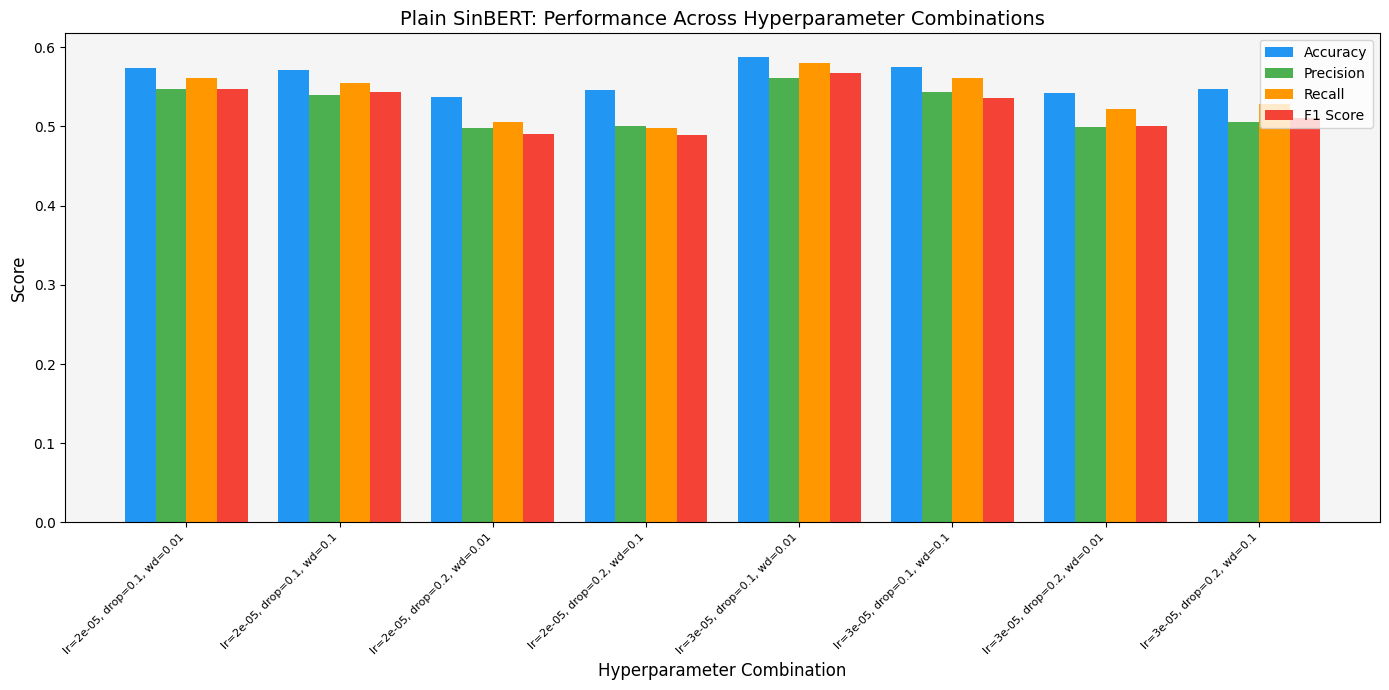

In [15]:
accuracies_hp = [r['accuracy'] for r in results]
precisions_hp = [r['precision'] for r in results]
recalls_hp = [r['recall'] for r in results]
f1s_hp = [r['f1'] for r in results]
labels_hp = [r['params'] for r in results]

fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(results))
width = 0.2

ax.bar([i - 1.5*width for i in x], accuracies_hp, width, label='Accuracy', color='#2196F3')
ax.bar([i - 0.5*width for i in x], precisions_hp, width, label='Precision', color='#4CAF50')
ax.bar([i + 0.5*width for i in x], recalls_hp, width, label='Recall', color='#FF9800')
ax.bar([i + 1.5*width for i in x], f1s_hp, width, label='F1 Score', color='#F44336')

ax.set_xlabel('Hyperparameter Combination', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Plain SinBERT: Performance Across Hyperparameter Combinations', fontsize=14)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_hp, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_facecolor('#f5f5f5')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.show()


### 5-Fold Cross-Validation with Best Hyperparameters


In [16]:
best_lr = best_result['learning_rate']
best_drop = best_result['dropout_rate']
best_wd = best_result['weight_decay']

k_folds = 5
kfolds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
texts = df['text'].tolist()
labels_cv = df['label'].values

fold_results = []
train_losses_all = []
val_losses_all = []
all_labels_cv = []
all_preds_cv = []

for fold, (train_idx, val_idx) in enumerate(kfolds.split(texts, labels_cv)):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{k_folds}")
    print(f"{'='*50}")

    train_texts = [texts[i] for i in train_idx]
    train_labels = [labels_cv[i] for i in train_idx]
    val_texts = [texts[i] for i in val_idx]
    val_labels = [labels_cv[i] for i in val_idx]

    train_dataset = SinhalaEmotionDataset(train_texts, train_labels, tokenizer)
    val_dataset = SinhalaEmotionDataset(val_texts, val_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    model = PlainSinBERT(
        num_labels=num_labels,
        dropout_rate=best_drop,
    ).to(device)
    freeze_bottom_layers(model)

    optimizer = AdamW(model.parameters(), lr=best_lr, weight_decay=best_wd)

    # Per-fold class weights from training fold only
    fold_label_counts = np.array([train_labels.count(t) for t in sorted(set(train_labels))])
    fold_weight = 1. / fold_label_counts
    fold_class_weights = torch.tensor(fold_weight, dtype=torch.float).to(device)
    fold_criterion = nn.CrossEntropyLoss(weight=fold_class_weights)

    train_losses, train_accuracies, val_losses, val_accuracies = train_model_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=fold_criterion,
        optimizer=optimizer,
        device=device,
        epochs=10,
        patience=2
    )

    train_losses_all.append(train_losses)
    val_losses_all.append(val_losses)

    acc, precision, recall, f1 = evaluate_metrics(model, val_loader, device)

    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].cpu().numpy()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds_batch = torch.argmax(outputs, dim=1).cpu().numpy()
            all_labels_cv.extend(labels_batch)
            all_preds_cv.extend(preds_batch)

    fold_results.append({
        'fold': fold + 1,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    print(f"Fold {fold+1} → Acc: {acc:.4f}, Prec: {precision:.4f}, Rec: {recall:.4f}, F1: {f1:.4f}")



Fold 1/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 595,206/125,982,726 (0.5%)
Epoch 1/10 - Train Loss: 1.6033, Train Acc: 0.3895, Val Loss: 1.4586, Val Acc: 0.4882
Epoch 2/10 - Train Loss: 1.4024, Train Acc: 0.5086, Val Loss: 1.3715, Val Acc: 0.4895
Epoch 3/10 - Train Loss: 1.3050, Train Acc: 0.5424, Val Loss: 1.3499, Val Acc: 0.4908
Epoch 4/10 - Train Loss: 1.2715, Train Acc: 0.5372, Val Loss: 1.3040, Val Acc: 0.5132
Epoch 5/10 - Train Loss: 1.2360, Train Acc: 0.5480, Val Loss: 1.2902, Val Acc: 0.5053
Epoch 6/10 - Train Loss: 1.2153, Train Acc: 0.5572, Val Loss: 1.2686, Val Acc: 0.5171
Epoch 7/10 - Train Loss: 1.1810, Train Acc: 0.5539, Val Loss: 1.2625, Val Acc: 0.5250
Epoch 8/10 - Train Loss: 1.1654, Train Acc: 0.5773, Val Loss: 1.2536, Val Acc: 0.5382
Epoch 9/10 - Train Loss: 1.1474, Train Acc: 0.5717, Val Loss: 1.2449, Val Acc: 0.5329
Epoch 10/10 - Train Loss: 1.1452, Train Acc: 0.5891, Val Loss: 1.2423, Val Acc: 0.5368
Fold 1 → Acc: 0.5368, Prec: 0.5031, Rec: 0.5278, F1: 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 595,206/125,982,726 (0.5%)
Epoch 1/10 - Train Loss: 1.6029, Train Acc: 0.4102, Val Loss: 1.4498, Val Acc: 0.5066
Epoch 2/10 - Train Loss: 1.4093, Train Acc: 0.5062, Val Loss: 1.3434, Val Acc: 0.5145
Epoch 3/10 - Train Loss: 1.3186, Train Acc: 0.5253, Val Loss: 1.2959, Val Acc: 0.5316
Epoch 4/10 - Train Loss: 1.2746, Train Acc: 0.5385, Val Loss: 1.2625, Val Acc: 0.5421
Epoch 5/10 - Train Loss: 1.2378, Train Acc: 0.5572, Val Loss: 1.2409, Val Acc: 0.5539
Epoch 6/10 - Train Loss: 1.2136, Train Acc: 0.5595, Val Loss: 1.2223, Val Acc: 0.5618
Epoch 7/10 - Train Loss: 1.2038, Train Acc: 0.5605, Val Loss: 1.2144, Val Acc: 0.5658
Epoch 8/10 - Train Loss: 1.1725, Train Acc: 0.5674, Val Loss: 1.2042, Val Acc: 0.5658
Epoch 9/10 - Train Loss: 1.1562, Train Acc: 0.5806, Val Loss: 1.1963, Val Acc: 0.5697
Epoch 10/10 - Train Loss: 1.1537, Train Acc: 0.5671, Val Loss: 1.1882, Val Acc: 0.5816
Fold 4 → Acc: 0.5816, Prec: 0.5511, Rec: 0.5577, F1: 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 595,206/125,982,726 (0.5%)
Epoch 1/10 - Train Loss: 1.6076, Train Acc: 0.3924, Val Loss: 1.4324, Val Acc: 0.5105
Epoch 2/10 - Train Loss: 1.4061, Train Acc: 0.5115, Val Loss: 1.3343, Val Acc: 0.5289
Epoch 3/10 - Train Loss: 1.3197, Train Acc: 0.5289, Val Loss: 1.2874, Val Acc: 0.5474
Epoch 4/10 - Train Loss: 1.2796, Train Acc: 0.5332, Val Loss: 1.2583, Val Acc: 0.5500
Epoch 5/10 - Train Loss: 1.2482, Train Acc: 0.5523, Val Loss: 1.2363, Val Acc: 0.5566
Epoch 6/10 - Train Loss: 1.2120, Train Acc: 0.5592, Val Loss: 1.2244, Val Acc: 0.5632
Epoch 7/10 - Train Loss: 1.1946, Train Acc: 0.5651, Val Loss: 1.2228, Val Acc: 0.5776
Epoch 8/10 - Train Loss: 1.1752, Train Acc: 0.5658, Val Loss: 1.2232, Val Acc: 0.5447
Epoch 9/10 - Train Loss: 1.1639, Train Acc: 0.5727, Val Loss: 1.1975, Val Acc: 0.5829
Epoch 10/10 - Train Loss: 1.1522, Train Acc: 0.5905, Val Loss: 1.1992, Val Acc: 0.5763
Fold 5 → Acc: 0.5763, Prec: 0.5376, Rec: 0.5636, F1: 

### Cross-Validation Results


In [17]:
print("\n" + "="*60)
print("5-Fold Cross-Validation Results (Plain SinBERT)")
print("="*60)
for r in fold_results:
    print(f"  Fold {r['fold']}: Acc={r['accuracy']:.4f}, Prec={r['precision']:.4f}, Rec={r['recall']:.4f}, F1={r['f1']:.4f}")

print("\n--- Macro Performance (Averaged Across Folds) ---")
avg_accuracy = np.mean([r['accuracy'] for r in fold_results])
avg_precision = np.mean([r['precision'] for r in fold_results])
avg_recall = np.mean([r['recall'] for r in fold_results])
avg_f1 = np.mean([r['f1'] for r in fold_results])

accuracies_cv = [r['accuracy'] for r in fold_results]
precisions_cv = [r['precision'] for r in fold_results]
recalls_cv = [r['recall'] for r in fold_results]
f1s_cv = [r['f1'] for r in fold_results]

print(f"  Average Accuracy:  {avg_accuracy:.4f} ± {np.std(accuracies_cv):.4f}")
print(f"  Average Precision: {avg_precision:.4f} ± {np.std(precisions_cv):.4f}")
print(f"  Average Recall:    {avg_recall:.4f} ± {np.std(recalls_cv):.4f}")
print(f"  Average F1 Score:  {avg_f1:.4f} ± {np.std(f1s_cv):.4f}")



5-Fold Cross-Validation Results (Plain SinBERT)
  Fold 1: Acc=0.5368, Prec=0.5031, Rec=0.5278, F1=0.5064
  Fold 2: Acc=0.5921, Prec=0.5509, Rec=0.5612, F1=0.5528
  Fold 3: Acc=0.5724, Prec=0.5459, Rec=0.5653, F1=0.5409
  Fold 4: Acc=0.5816, Prec=0.5511, Rec=0.5577, F1=0.5500
  Fold 5: Acc=0.5763, Prec=0.5376, Rec=0.5636, F1=0.5453

--- Macro Performance (Averaged Across Folds) ---
  Average Accuracy:  0.5718 ± 0.0187
  Average Precision: 0.5377 ± 0.0180
  Average Recall:    0.5551 ± 0.0139
  Average F1 Score:  0.5391 ± 0.0168


### Per-Fold Metrics Bar Chart


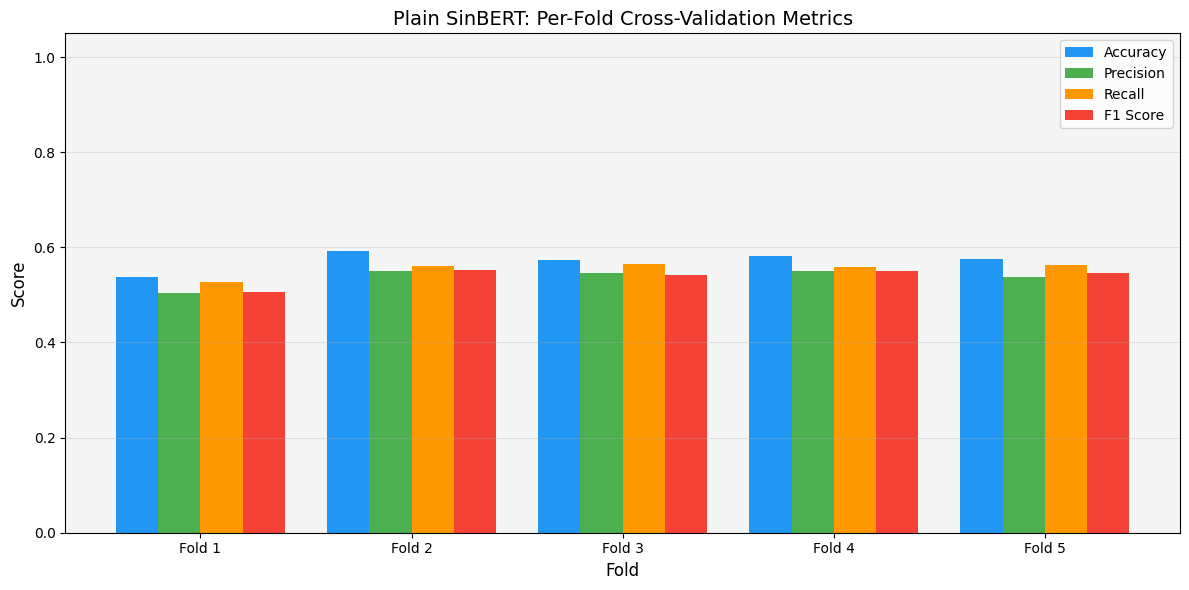

In [19]:
fold_nums = [f"Fold {r['fold']}" for r in fold_results]
x = np.arange(len(fold_nums))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accuracies_cv, width, label='Accuracy', color='#2196F3')
ax.bar(x - 0.5*width, precisions_cv, width, label='Precision', color='#4CAF50')
ax.bar(x + 0.5*width, recalls_cv, width, label='Recall', color='#FF9800')
ax.bar(x + 1.5*width, f1s_cv, width, label='F1 Score', color='#F44336')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Plain SinBERT: Per-Fold Cross-Validation Metrics', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(fold_nums)
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f5f5f5')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.show()


### Training and Validation Loss Plot (Averaged Across Folds)


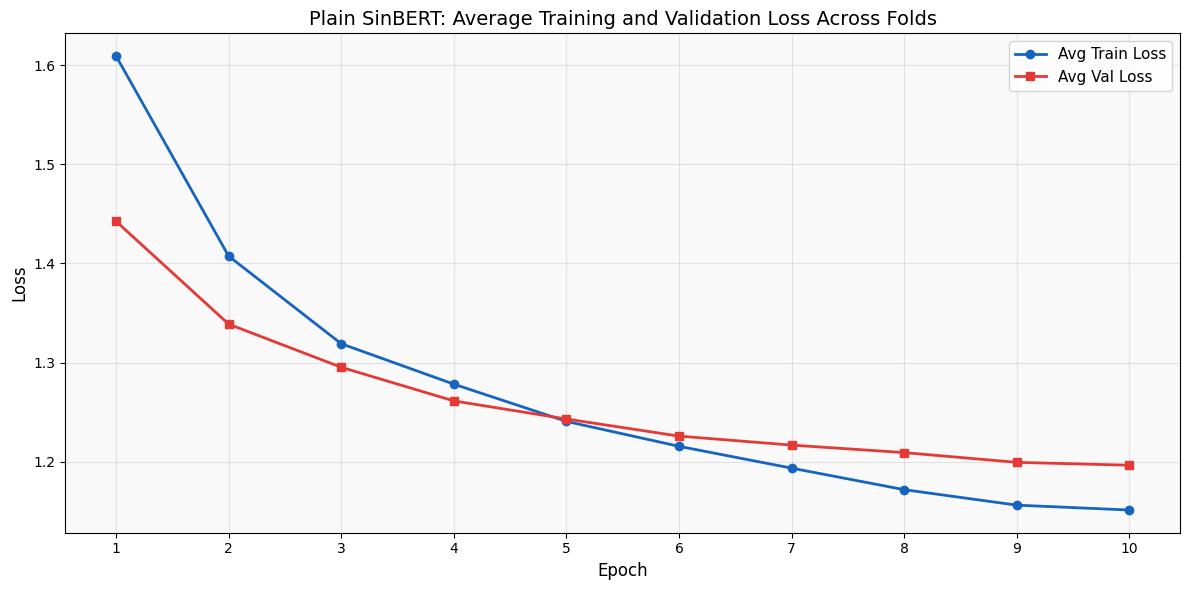

In [21]:
min_len = min(len(l) for l in train_losses_all)
train_losses_trimmed = [l[:min_len] for l in train_losses_all]
val_losses_trimmed = [l[:min_len] for l in val_losses_all]

avg_train_loss = np.mean(train_losses_trimmed, axis=0)
avg_val_loss = np.mean(val_losses_trimmed, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, len(avg_train_loss)+1), avg_train_loss, marker='o', label='Avg Train Loss', color='#1565C0', linewidth=2)
ax.plot(range(1, len(avg_val_loss)+1), avg_val_loss, marker='s', label='Avg Val Loss', color='#E53935', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Plain SinBERT: Average Training and Validation Loss Across Folds', fontsize=14)
ax.set_xticks(range(1, len(avg_train_loss)+1))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.show()


### Per-Fold Loss Curves


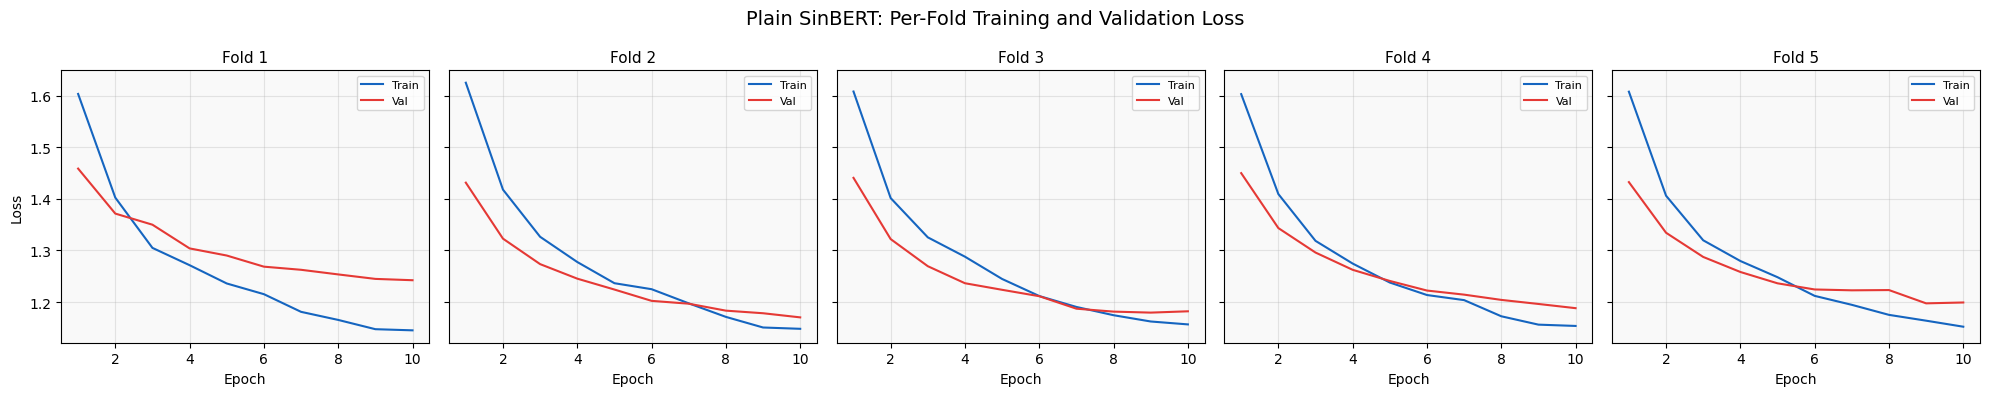

In [23]:
fig, axes = plt.subplots(1, k_folds, figsize=(20, 4), sharey=True)
for i in range(k_folds):
    axes[i].plot(range(1, len(train_losses_all[i])+1), train_losses_all[i], label='Train', color='#1565C0')
    axes[i].plot(range(1, len(val_losses_all[i])+1), val_losses_all[i], label='Val', color='#E53935')
    axes[i].set_title(f'Fold {i+1}', fontsize=11)
    axes[i].set_xlabel('Epoch')
    if i == 0:
        axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_facecolor('#f9f9f9')

fig.suptitle('Plain SinBERT: Per-Fold Training and Validation Loss', fontsize=14)
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.show()


### Confusion Matrix (Global / Micro Performance)


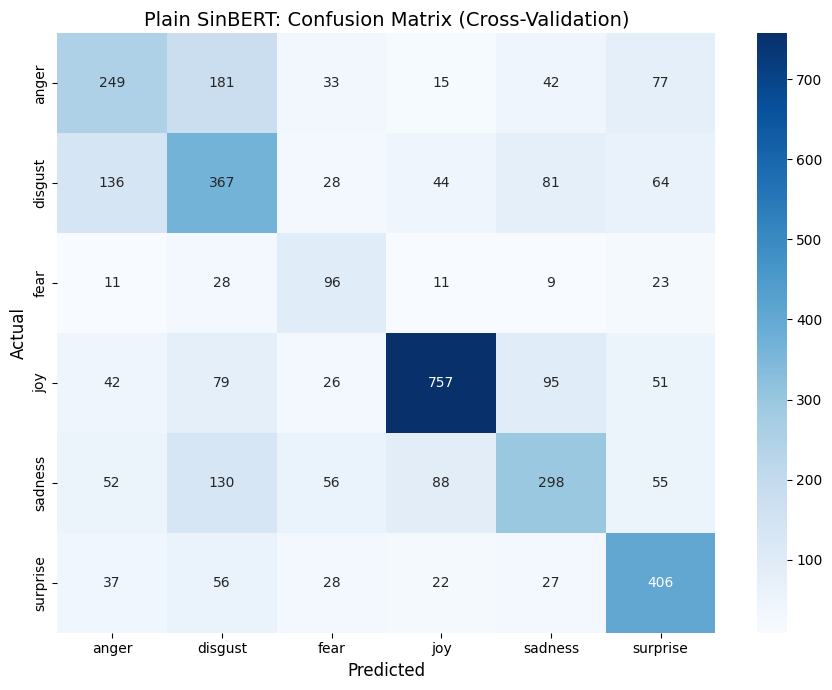

In [25]:
emotion_names = sorted(set(df['label'].values))

cm = confusion_matrix(all_labels_cv, all_preds_cv)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_names, yticklabels=emotion_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Plain SinBERT: Confusion Matrix (Cross-Validation)', fontsize=14)
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.show()


### Classification Report


In [26]:
print("\nDetailed Classification Report (Cross-Validation):")
print(classification_report(all_labels_cv, all_preds_cv, target_names=emotion_names))



Detailed Classification Report (Cross-Validation):
              precision    recall  f1-score   support

       anger       0.47      0.42      0.44       597
     disgust       0.44      0.51      0.47       720
        fear       0.36      0.54      0.43       178
         joy       0.81      0.72      0.76      1050
     sadness       0.54      0.44      0.48       679
    surprise       0.60      0.70      0.65       576

    accuracy                           0.57      3800
   macro avg       0.54      0.56      0.54      3800
weighted avg       0.58      0.57      0.57      3800



### Micro Performance Metrics


In [27]:
micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
    all_labels_cv, all_preds_cv, average='micro'
)
print("--- Micro Performance (Global) ---")
print(f"  Micro Precision: {micro_precision:.4f}")
print(f"  Micro Recall:    {micro_recall:.4f}")
print(f"  Micro F1 Score:  {micro_f1:.4f}")


--- Micro Performance (Global) ---
  Micro Precision: 0.5718
  Micro Recall:    0.5718
  Micro F1 Score:  0.5718


### Per-Class Performance Bar Chart


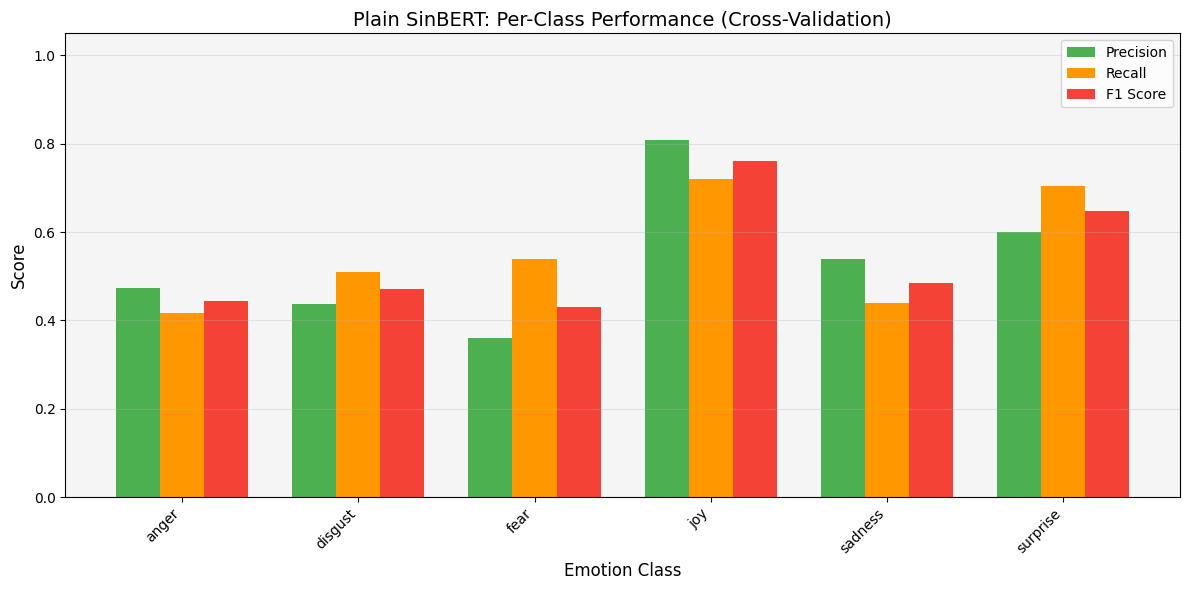

In [29]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
    all_labels_cv, all_preds_cv, average=None
)

x = np.arange(len(emotion_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, per_class_precision, width, label='Precision', color='#4CAF50')
ax.bar(x, per_class_recall, width, label='Recall', color='#FF9800')
ax.bar(x + width, per_class_f1, width, label='F1 Score', color='#F44336')

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Plain SinBERT: Per-Class Performance (Cross-Validation)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(emotion_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f5f5f5')
fig.patch.set_facecolor('#ffffff')
plt.tight_layout()
plt.show()


### Summary for Comparison
Use these final metrics to compare **Plain SinBERT** with **SinBERT+CNN**:


In [30]:
print("="*60)
print("PLAIN SinBERT — FINAL COMPARISON METRICS")
print("="*60)
print(f"\n  Best Hyperparameters: {best_result['params']}")
print(f"  Optimizer: AdamW (lr={best_lr}, weight_decay={best_wd})")
print(f"  Dropout: {best_drop}")
print(f"\n  Macro Accuracy:  {avg_accuracy:.4f} ± {np.std(accuracies_cv):.4f}")
print(f"  Macro Precision: {avg_precision:.4f} ± {np.std(precisions_cv):.4f}")
print(f"  Macro Recall:    {avg_recall:.4f} ± {np.std(recalls_cv):.4f}")
print(f"  Macro F1 Score:  {avg_f1:.4f} ± {np.std(f1s_cv):.4f}")
print(f"\n  Micro Precision: {micro_precision:.4f}")
print(f"  Micro Recall:    {micro_recall:.4f}")
print(f"  Micro F1 Score:  {micro_f1:.4f}")
print("="*60)


PLAIN SinBERT — FINAL COMPARISON METRICS

  Best Hyperparameters: lr=3e-05, drop=0.1, wd=0.01
  Optimizer: AdamW (lr=3e-05, weight_decay=0.01)
  Dropout: 0.1

  Macro Accuracy:  0.5718 ± 0.0187
  Macro Precision: 0.5377 ± 0.0180
  Macro Recall:    0.5551 ± 0.0139
  Macro F1 Score:  0.5391 ± 0.0168

  Micro Precision: 0.5718
  Micro Recall:    0.5718
  Micro F1 Score:  0.5718


### Final Test Set Evaluation
Train one model on the full 80% training split with best hyperparameters and evaluate once on the held-out 20% test set.

In [31]:
final_model = PlainSinBERT(
    num_labels=num_labels,
    dropout_rate=best_drop,
).to(device)
freeze_bottom_layers(final_model)

optimizer = AdamW(final_model.parameters(), lr=best_lr, weight_decay=best_wd)
criterion_final = nn.CrossEntropyLoss(weight=class_weights)

train_model_with_early_stopping(
    model=final_model,
    train_loader=train_data_loader,
    val_loader=test_data_loader,
    criterion=criterion_final,
    optimizer=optimizer,
    device=device,
    epochs=10,
    patience=2
)

acc, precision, recall, f1 = evaluate_metrics(final_model, test_data_loader, device)
print('=' * 50)
print('Final Test Set Evaluation (Plain SinBERT)')
print('=' * 50)
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 595,206/125,982,726 (0.5%)
Epoch 1/10 - Train Loss: 1.6177, Train Acc: 0.3984, Val Loss: 1.4468, Val Acc: 0.4829
Epoch 2/10 - Train Loss: 1.4159, Train Acc: 0.4980, Val Loss: 1.3233, Val Acc: 0.4947
Epoch 3/10 - Train Loss: 1.3278, Train Acc: 0.5260, Val Loss: 1.2638, Val Acc: 0.5145
Epoch 4/10 - Train Loss: 1.2800, Train Acc: 0.5322, Val Loss: 1.2191, Val Acc: 0.5395
Epoch 5/10 - Train Loss: 1.2514, Train Acc: 0.5549, Val Loss: 1.1896, Val Acc: 0.5487
Epoch 6/10 - Train Loss: 1.2224, Train Acc: 0.5543, Val Loss: 1.1689, Val Acc: 0.5645
Epoch 7/10 - Train Loss: 1.1993, Train Acc: 0.5632, Val Loss: 1.1482, Val Acc: 0.5711
Epoch 8/10 - Train Loss: 1.1892, Train Acc: 0.5697, Val Loss: 1.1422, Val Acc: 0.5724
Epoch 9/10 - Train Loss: 1.1704, Train Acc: 0.5757, Val Loss: 1.1326, Val Acc: 0.5671
Epoch 10/10 - Train Loss: 1.1603, Train Acc: 0.5641, Val Loss: 1.1259, Val Acc: 0.5816
Final Test Set Evaluation (Plain SinBERT)
Accuracy:  